# 03 · Logistic regression
Walk-forward results, calibration, and what the model learned.

- **Tuning seasons (2012–2018)** were used to choose feature settings and the regularization strength `C`.
- **Holdout seasons (2019–2025)** were not used for any choice, so they are the honest estimate.

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.evaluate import load_played_games, walk_forward, compare, baseline_predictions
from src.features import FEATURE_COLUMNS
from src.train import MODELS, coefficients

games = load_played_games()
preds = walk_forward(games, MODELS['logistic'], FEATURE_COLUMNS, range(2012, 2026))
hold = preds[preds.season >= 2019]
compare(games, {'logistic': hold}).round(4)

,accuracy,log_loss,brier,games
vegas,0.6638,0.6083,0.2105,1954
logistic,0.6474,0.6295,0.2199,1954
elo,0.6382,0.6367,0.2227,1954


## Calibration
Group holdout games by predicted probability and compare with how often the home team actually won. A well-calibrated model sits on the diagonal.

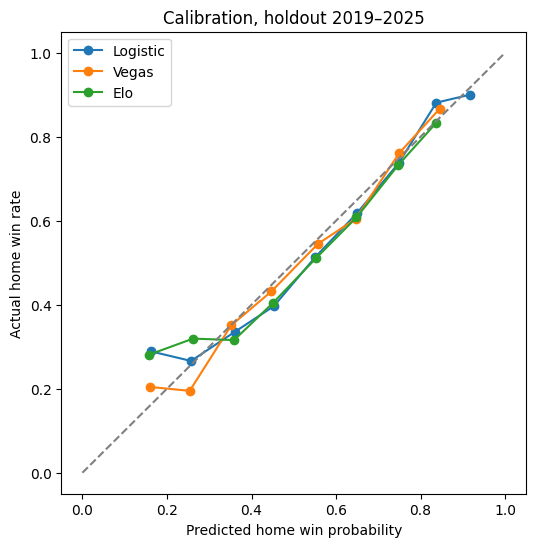

In [2]:
df = games[['game_id', 'home_win']].merge(hold).merge(baseline_predictions(games)).dropna()
bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(6, 6))
for col, label in [('p_home', 'Logistic'), ('p_vegas', 'Vegas'), ('p_elo', 'Elo')]:
    b = pd.cut(df[col], bins)
    cal = df.groupby(b, observed=True).agg(pred=(col, 'mean'), actual=('home_win', 'mean'), n=('home_win', 'size'))
    cal = cal[cal.n >= 20]
    ax.plot(cal.pred, cal.actual, marker='o', label=label)
ax.plot([0, 1], [0, 1], ls='--', c='gray')
ax.set_xlabel('Predicted home win probability'); ax.set_ylabel('Actual home win rate'); ax.legend()
ax.set_title('Calibration, holdout 2019–2025'); plt.show()

## Season by season

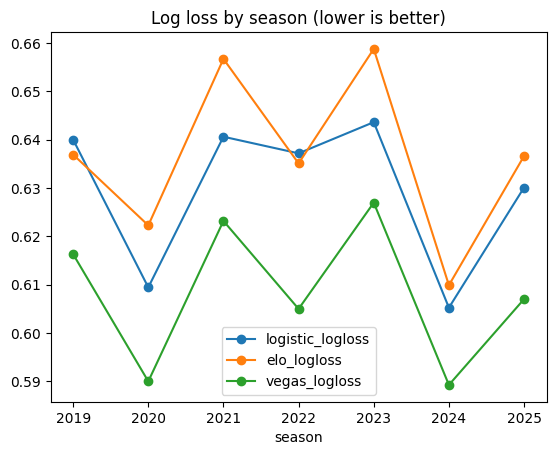

In [3]:
from src.evaluate import metrics
rows = []
for s, d in df.groupby('season'):
    rows.append({'season': s, **{f'{n}_logloss': metrics(d.home_win, d[c])['log_loss'] for n, c in [('logistic', 'p_home'), ('elo', 'p_elo'), ('vegas', 'p_vegas')]}})
pd.DataFrame(rows).set_index('season').plot(marker='o', title='Log loss by season (lower is better)'); plt.show()

## What the model learned
Coefficients on standardized features: the change in log-odds of a home win when the home-minus-away gap grows by one standard deviation. Positive favors the home team.

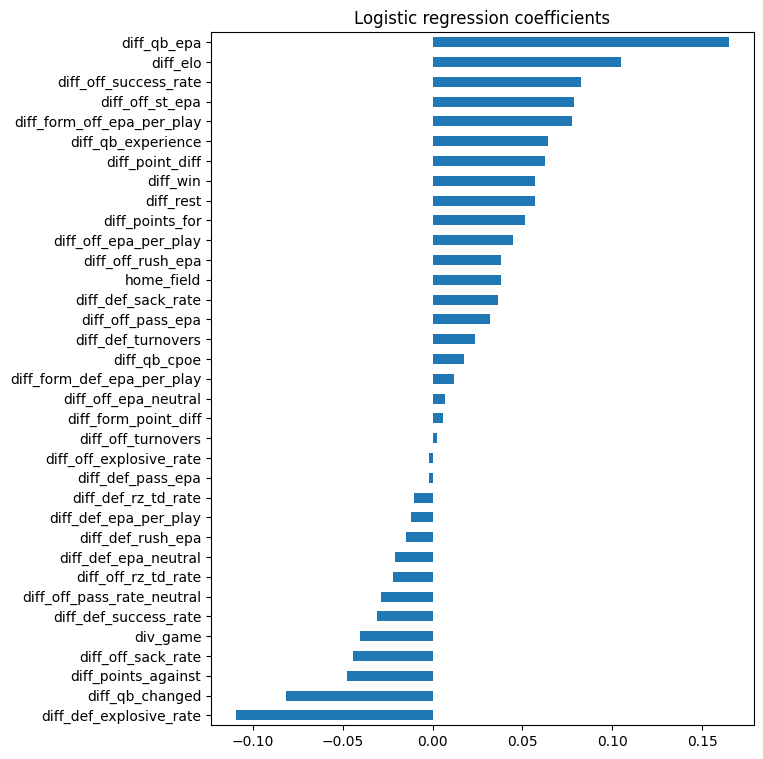

Intercept (home-field baseline): 0.268 -> P(home win) for evenly matched teams = 0.567


In [4]:
final = MODELS['logistic']().fit(games[FEATURE_COLUMNS], games.home_win)
coef = coefficients(final)
coef.sort_values().plot.barh(figsize=(7, 9), title='Logistic regression coefficients'); plt.show()
print('Intercept (home-field baseline):', round(final.named_steps['clf'].intercept_[0], 3),
      '-> P(home win) for evenly matched teams =', round(1 / (1 + np.exp(-final.named_steps['clf'].intercept_[0])), 3))